In [51]:
import pandas as pd
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [31]:
raw_dataset = fetch_california_housing()
print(raw_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [32]:
house_price_dataset = pd.DataFrame(data = raw_dataset.data,columns=raw_dataset.feature_names)
house_price_dataset["Target"] = raw_dataset.target

In [33]:
house_price_dataset.shape

(20640, 9)

In [34]:
house_price_dataset.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Target        float64
dtype: object

In [35]:
house_price_dataset.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

In [36]:
house_price_dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [37]:
X = pd.DataFrame(data = raw_dataset.data,columns=raw_dataset.feature_names)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [85]:
y = raw_dataset.target

In [86]:
#Data Preparation
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=9,shuffle=True)

In [87]:
#Model selection
linearmodel = LinearRegression()
ridgeregression = Ridge()
lassoregression = Lasso()
elasticnetregression = ElasticNet()

In [88]:
linearmodel.fit(X_train,y_train)
values = linearmodel.coef_
print(values)

[ 4.48279312e-01  9.52132056e-03 -1.27608638e-01  8.41842128e-01
  5.94206528e-08 -4.77815802e-03 -4.19168711e-01 -4.33143104e-01]


In [89]:
ridgeregression.fit(X_train,y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [90]:
lassoregression.fit(X_train,y_train)


,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [91]:
elasticnetregression.fit(X_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


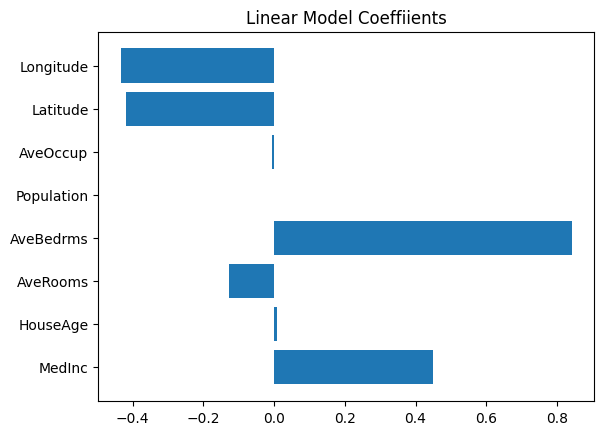

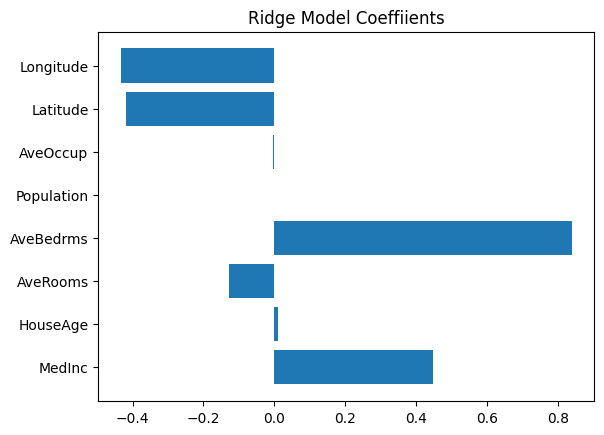

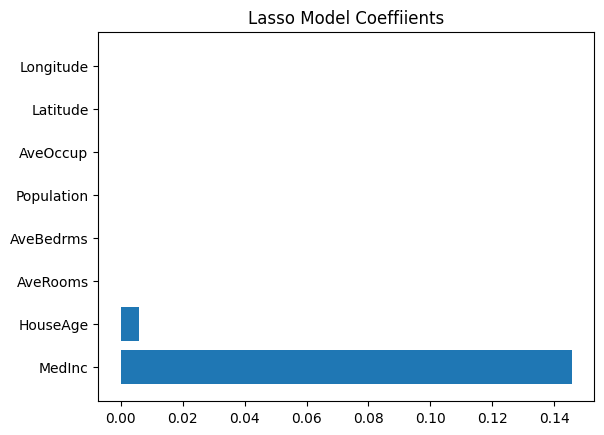

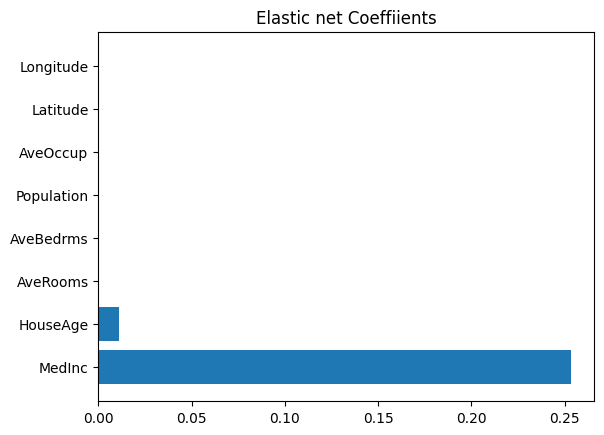

In [92]:
def plot_coefficient_values(model,graph_title):
    plot_points_dataframe = pd.DataFrame({"x_points" : model.coef_,
                             "y_points" : model.feature_names_in_})
    plt.barh(plot_points_dataframe["y_points"],plot_points_dataframe["x_points"])
    plt.title(graph_title)
    plt.show()

plot_coefficient_values(linearmodel,"Linear Model Coeffiients")
plot_coefficient_values(ridgeregression,"Ridge Model Coeffiients")
plot_coefficient_values(lassoregression,"Lasso Model Coeffiients")
plot_coefficient_values(elasticnetregression,"Elastic net Coeffiients")

In [93]:
#Model testing
y_pred_linearregression = linearmodel.predict(X_test)
y_pred_ridgeregression = ridgeregression.predict(X_test)
y_pred_lassoregression = lassoregression.predict(X_test)
y_pred_elasticnetregression = elasticnetregression.predict(X_test)

In [94]:
#model evaluation
print(mean_absolute_error(y_test,y_pred_linearregression))
print(mean_absolute_error(y_test,y_pred_ridgeregression))
print(mean_absolute_error(y_test,y_pred_lassoregression))
print(mean_absolute_error(y_test,y_pred_elasticnetregression))

0.5337202255972634
0.5337188539843429
0.7689562724178659
0.6805030172969938
